In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scanpy.external as sce
import pandas as pd
import seaborn as sns
import os
import anndata as ad
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor="white")

### 2.读取数据

正常情况：10X的输入数据是固定的三个文件，在工作目录下新建01_data/，把三个文件放进去。

In [ ]:
parent_dir = "path/to/your/parent_folder" 
# 创建一个空字典，用于临时存放每个样本的 AnnData 对象
adata_dict = {}
# ==========================================
# 2. 遍历文件夹并逐个读取
# ==========================================
for sample_name in os.listdir(parent_dir):
    sample_path = os.path.join(parent_dir, sample_name)
    # 确保它是一个文件夹，跳过像 .DS_Store 这样的隐藏文件
    if os.path.isdir(sample_path):
        print(f"正在读取样本: {sample_name} ...")
        
        # 读取 10X 数据
        adata = sc.read_10x_mtx(
            sample_path,
            var_names='gene_symbols',  
            cache=True                 
        )
        # 确保基因名称唯一
        adata.var_names_make_unique()
        
        # 将读取好的数据放入字典，Key 为样本名
        adata_dict[sample_name] = adata

print(f"\n成功读取 {len(adata_dict)} 个样本，准备合并...")

# ==========================================
# 3. 合并所有样本 (核心步骤)
# ==========================================
# 使用 ad.concat 进行合并
adata= ad.concat(
    adata_dict, 
    label="orig.ident",     # 自动在 obs 中新建一列叫 'sample_id'，记录数据来源于哪个字典的 Key
    index_unique="-"       # 极其重要：在原有的细胞 Barcode 后面加上 '-样本名' 以防止名字冲突
)

In [2]:
adata = sc.read_csv("./counts_py.csv")
adata.obs = pd.read_csv("./meta.csv",index_col=0)
adata.var["Gene"] = adata.var_names
adata.obs["CellID"] = adata.obs_names
adata.var_names_make_unique()

In [7]:
#过滤后
adata.X.shape #可以看到过滤前后的细胞数量和基因数量

(2700, 13714)

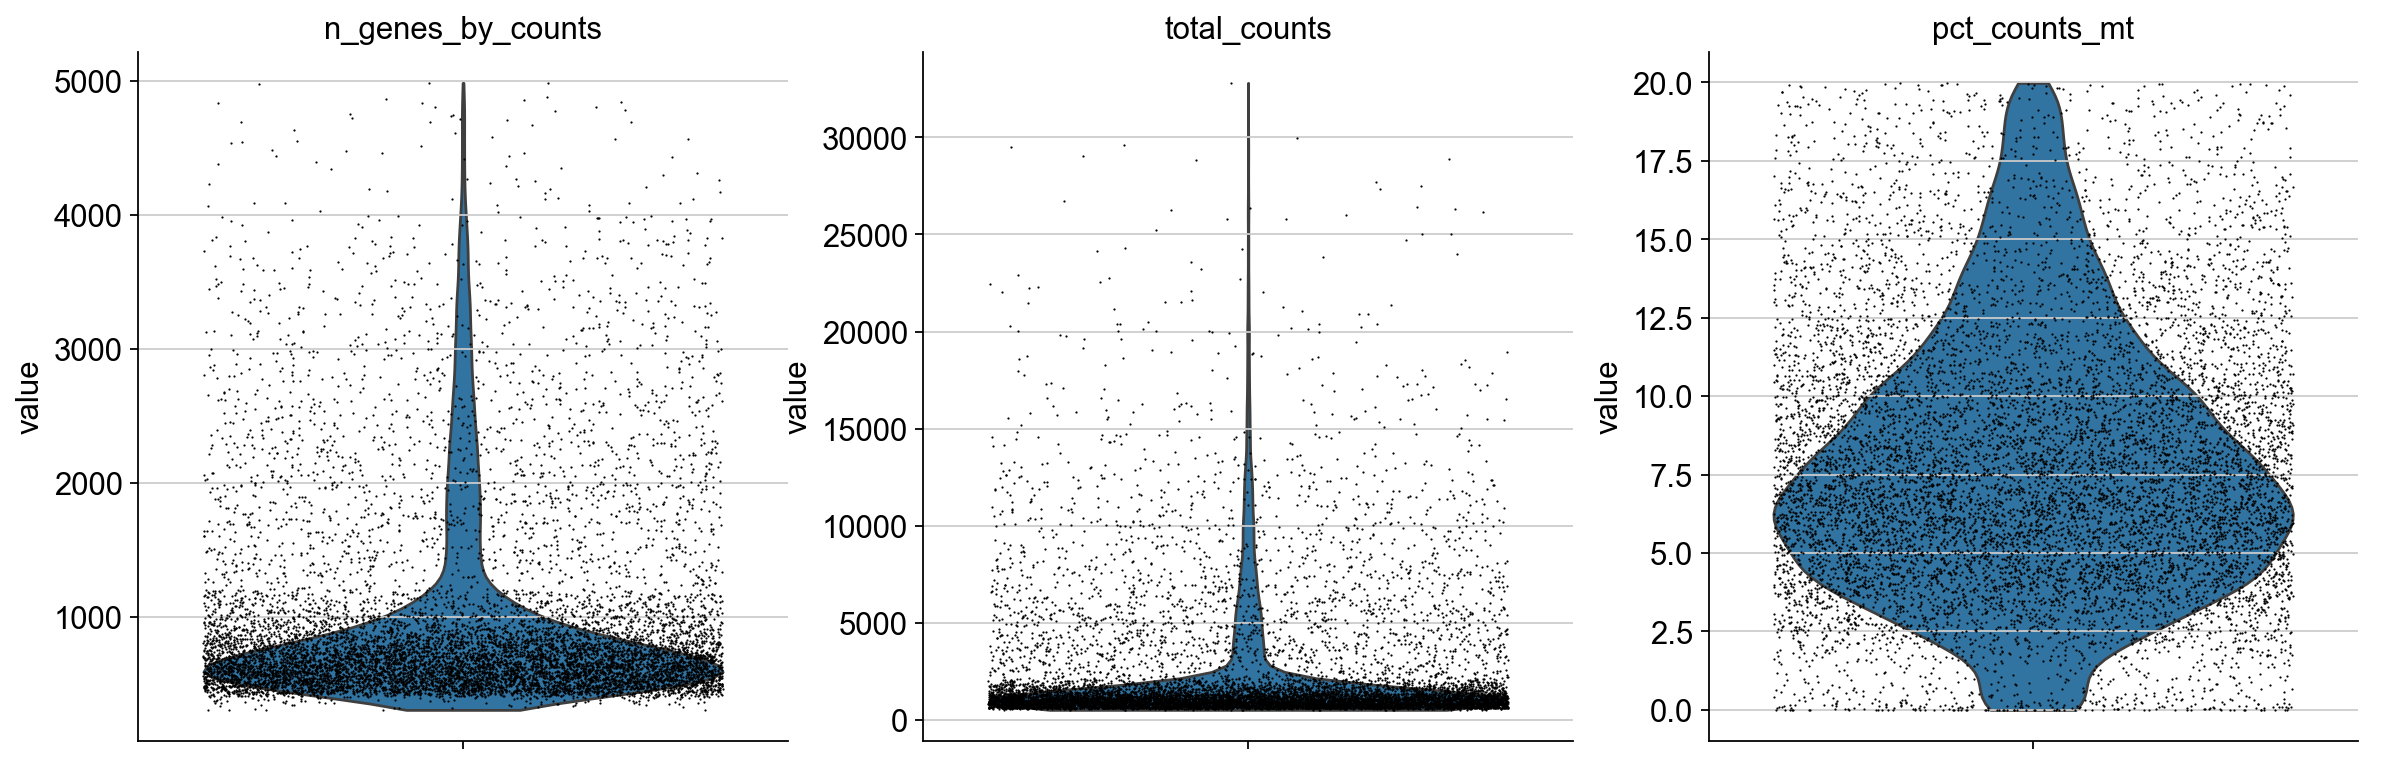

In [3]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [4]:
sc.pp.filter_cells(adata, min_genes=200)       # 过滤掉表达基因数少于200的细胞 (可能是死细胞或碎片)
sc.pp.filter_genes(adata, min_cells=3)         # 过滤掉在少于3个细胞中表达的基因
adata = adata[adata.obs.n_genes_by_counts < 5000, :] # 过滤掉表达基因数异常高的细胞 (可能是双细胞 Doublets)
# NOTE: 线粒体比例阈值从 20% 修正为 10%，与论文 QC 标准一致
adata = adata[adata.obs.pct_counts_mt < 10, :]        # 过滤掉线粒体基因比例大于10%的细胞 (通常为死细胞)

filtered out 2909 genes that are detected in less than 3 cells


In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata) # Log转换：log(1 + x)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
# 回归掉总count数和线粒体比例带来的影响（可选，耗时较长）
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
# 数据标准化为均值为0，方差为1，限制最大值为10以消除极端离群值的影响
sc.pp.scale(adata, max_value=10)

f:\miniconda\envs\scanpy\lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
regressing out ['total_counts', 'pct_counts_mt']


f:\miniconda\envs\scanpy\lib\site-packages\scanpy\preprocessing\_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:01)


In [10]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent_mito,percent_ribo,percent_hb,RNA_snn_res.0.01,seurat_clusters,RNA_snn_res.0.05,RNA_snn_res.0.1,...,new_celltype,RNA_snn_res.0.4,RNA_snn_res.0.6,CellID,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,leiden
T1_AAAGGATCACACCAGC.1,T1,5217,1908,11.788384,20.088173,0.000000,1,4,1,1,...,high_Epi,1,1,T1_AAAGGATCACACCAGC.1,1908,5217.0,615.0,11.788383,1908,6
T1_AAAGTGAAGGTTCCGC.1,T1,6672,1985,0.959233,31.954436,0.044964,1,3,1,1,...,high_Epi,1,1,T1_AAAGTGAAGGTTCCGC.1,1985,6672.0,64.0,0.959233,1985,6
T1_AACACACCACCGTCTT.1,T1,10781,2924,8.533531,24.005194,0.000000,1,4,1,1,...,high_Epi,1,1,T1_AACACACCACCGTCTT.1,2924,10781.0,920.0,8.533531,2924,6
T1_AACACACGTCCCTAAA.1,T1,1134,699,4.585538,21.781305,0.000000,1,6,1,1,...,low_Epi,3,3,T1_AACACACGTCCCTAAA.1,699,1134.0,52.0,4.585538,699,6
T1_AACACACGTTAATCGC.1,T1,27328,4743,0.735509,20.323478,0.000000,1,13,1,1,...,high_Epi,1,7,T1_AACACACGTTAATCGC.1,4743,27328.0,201.0,0.735509,4743,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N2_TTTAGTCTCTGTTGGA.1,N2,922,436,0.433839,2.060738,0.000000,1,0,1,0,...,low_Epi,0,0,N2_TTTAGTCTCTGTTGGA.1,436,922.0,4.0,0.433839,436,9
N2_TTTCACATCCATCTGC.1,N2,3838,1680,9.874935,18.030224,0.078166,1,7,1,2,...,high_Epi,6,4,N2_TTTCACATCCATCTGC.1,1680,3838.0,379.0,9.874935,1680,0
N2_TTTGACTCACGGCGTT.1,N2,643,481,10.886470,12.441680,0.000000,1,6,1,1,...,low_Epi,3,3,N2_TTTGACTCACGGCGTT.1,481,643.0,70.0,10.886470,481,3
N2_TTTGGAGGTGCCAAGA.1,N2,6695,2413,7.513069,12.352502,0.029873,1,2,1,2,...,high_Epi,2,2,N2_TTTGGAGGTGCCAAGA.1,2413,6695.0,503.0,7.513069,2413,5


computing PCA
    with n_comps=50
    finished (0:00:02)


2026-04-22 10:47:29,998 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-22 10:47:32,880 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-22 10:47:32,943 - harmonypy - INFO - Iteration 1 of 10
2026-04-22 10:47:35,394 - harmonypy - INFO - Iteration 2 of 10
2026-04-22 10:47:37,802 - harmonypy - INFO - Iteration 3 of 10
2026-04-22 10:47:40,091 - harmonypy - INFO - Iteration 4 of 10
2026-04-22 10:47:42,381 - harmonypy - INFO - Iteration 5 of 10
2026-04-22 10:47:44,285 - harmonypy - INFO - Iteration 6 of 10
2026-04-22 10:47:46,115 - harmonypy - INFO - Iteration 7 of 10
2026-04-22 10:47:47,835 - harmonypy - INFO - Iteration 8 of 10
2026-04-22 10:47:49,836 - harmonypy - INFO - Iteration 9 of 10
2026-04-22 10:47:51,315 - harmonypy - INFO - Converged after 9 iterations


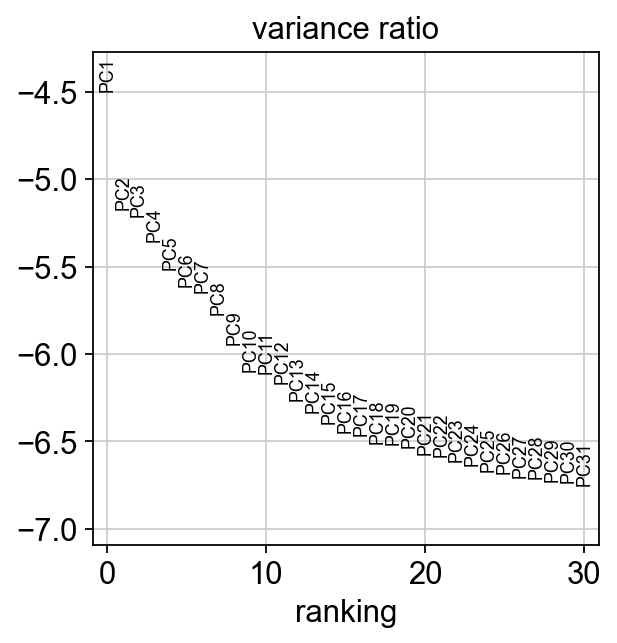

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
running Leiden clustering


C:\Users\kzy\AppData\Local\Temp\ipykernel_66800\260373570.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.1)


    finished: found 4 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


In [ ]:
sc.tl.pca(adata, svd_solver='arpack')
# 运行 Harmony 进行多样本整合
sce.pp.harmony_integrate(adata, 'orig.ident')
sc.pl.pca_variance_ratio(adata, log=True)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=20)
sc.tl.leiden(adata, resolution=0.4)   # NOTE: 论文使用 resolution=0.4，与 analyze.py 统一

In [9]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent_mito,percent_ribo,percent_hb,RNA_snn_res.0.01,seurat_clusters,RNA_snn_res.0.05,RNA_snn_res.0.1,...,new_celltype,RNA_snn_res.0.4,RNA_snn_res.0.6,CellID,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,leiden
T1_AAAGGATCACACCAGC.1,T1,5217,1908,11.788384,20.088173,0.000000,1,4,1,1,...,high_Epi,1,1,T1_AAAGGATCACACCAGC.1,1908,5217.0,615.0,11.788383,1908,6
T1_AAAGTGAAGGTTCCGC.1,T1,6672,1985,0.959233,31.954436,0.044964,1,3,1,1,...,high_Epi,1,1,T1_AAAGTGAAGGTTCCGC.1,1985,6672.0,64.0,0.959233,1985,6
T1_AACACACCACCGTCTT.1,T1,10781,2924,8.533531,24.005194,0.000000,1,4,1,1,...,high_Epi,1,1,T1_AACACACCACCGTCTT.1,2924,10781.0,920.0,8.533531,2924,6
T1_AACACACGTCCCTAAA.1,T1,1134,699,4.585538,21.781305,0.000000,1,6,1,1,...,low_Epi,3,3,T1_AACACACGTCCCTAAA.1,699,1134.0,52.0,4.585538,699,6
T1_AACACACGTTAATCGC.1,T1,27328,4743,0.735509,20.323478,0.000000,1,13,1,1,...,high_Epi,1,7,T1_AACACACGTTAATCGC.1,4743,27328.0,201.0,0.735509,4743,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N2_TTTAGTCTCTGTTGGA.1,N2,922,436,0.433839,2.060738,0.000000,1,0,1,0,...,low_Epi,0,0,N2_TTTAGTCTCTGTTGGA.1,436,922.0,4.0,0.433839,436,7
N2_TTTCACATCCATCTGC.1,N2,3838,1680,9.874935,18.030224,0.078166,1,7,1,2,...,high_Epi,6,4,N2_TTTCACATCCATCTGC.1,1680,3838.0,379.0,9.874935,1680,0
N2_TTTGACTCACGGCGTT.1,N2,643,481,10.886470,12.441680,0.000000,1,6,1,1,...,low_Epi,3,3,N2_TTTGACTCACGGCGTT.1,481,643.0,70.0,10.886470,481,4
N2_TTTGGAGGTGCCAAGA.1,N2,6695,2413,7.513069,12.352502,0.029873,1,2,1,2,...,high_Epi,2,2,N2_TTTGGAGGTGCCAAGA.1,2413,6695.0,503.0,7.513069,2413,2


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


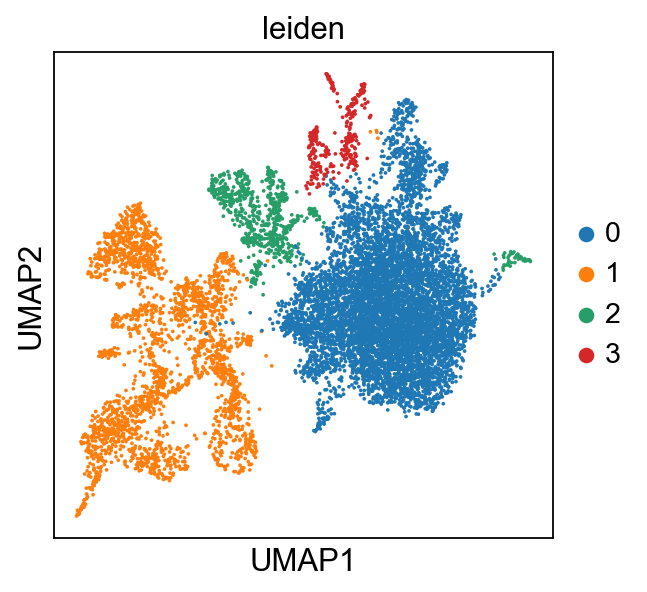

In [7]:
sc.tl.umap(adata)
# 绘制UMAP图，按聚类结果上色
sc.pl.umap(adata, color=['leiden'])

In [ ]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon",pts=True)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [ ]:
markers = sc.get.rank_genes_groups_df(adata,group=None)
print(markers)

       group  names     scores  logfoldchanges          pvals      pvals_adj  \
0          0   CCL5  25.488392        5.620503  2.651385e-143  3.636109e-139   
1          0   NKG7  22.801632        5.026347  4.417427e-115  3.029030e-111   
2          0    B2M  18.745281        0.748276   2.115543e-78   9.670853e-75   
3          0   GZMA  18.647177        4.055609   1.331246e-77   4.564178e-74   
4          0   CST7  18.530350        4.116673   1.175189e-76   3.223309e-73   
...      ...    ...        ...             ...            ...            ...   
123421     8  RPL32  -5.944178       -6.197451   2.778481e-09   1.851438e-06   
123422     8  RPS14  -5.950255       -6.020301   2.677241e-09   1.851438e-06   
123423     8  RPL13  -5.953674       -5.255808   2.621882e-09   1.851438e-06   
123424     8  RPL11  -5.964311       -5.901801   2.456689e-09   1.851438e-06   
123425     8  RPL10  -5.983304       -5.198582   2.186560e-09   1.851438e-06   

        pct_nz_group  pct_nz_reference 

In [11]:
# 1. 运行差异分析寻找 Marker
# 注意：Scanpy 默认会计算 scores, logfoldchanges 和 pvals_adj
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# 2. 将嵌套的字典结果提取为类似 Seurat 的长表格 (DataFrame)
# group=None 表示提取所有 cluster 的数据
marker_df = sc.get.rank_genes_groups_df(adata, group=None)

# 此时 marker_df 包含这几列: 'group'(也就是cluster), 'names'(基因名), 'scores', 'logfoldchanges', 'pvals', 'pvals_adj'


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:12)


In [15]:
marker_df.columns

Index(['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj'], dtype='object')

In [14]:

# 3. 获取每个 Cluster 中 logFC 排名前 15 的基因
# (相当于 R 里的 group_by(cluster) %>% top_n(15, logFC))
top15_markers = (
    marker_df
    # 过滤掉不显著的基因 (可选，但推荐)
    .query('pvals_adj < 0.05') 
    # 按 group (cluster) 分组
    .groupby('group')
    # 在每个组内，按 logfoldchanges 提取最大的 15 个
    .apply(lambda x: x.nlargest(15, 'logfoldchanges'))
    .reset_index(drop=True)
)

print(top15_markers)


   group         names     scores  logfoldchanges          pvals  \
0      0       SLC12A1  44.278023        5.131119   0.000000e+00   
1      0         WFDC2  72.759682        5.019483   0.000000e+00   
2      0          SIM2   4.154179        4.942157   3.264572e-05   
3      0         SFRP1  13.871942        4.934834   9.370602e-44   
4      0        TSPAN8  26.919729        4.898972  1.290602e-159   
5      0          UMOD  24.570057        4.877367  2.640642e-133   
6      0       C5orf38   4.151243        4.857208   3.306745e-05   
7      0          CASR   4.824452        4.838580   1.403888e-06   
8      0          IRX1   6.116260        4.654656   9.579694e-10   
9      0        PAPPA2  24.101767        4.646607  2.395355e-128   
10     0        CLDN16  11.213878        4.645284   3.485796e-29   
11     0         GABRP  11.986771        4.485612   4.168419e-33   
12     0          CDH3   4.516602        4.421559   6.283994e-06   
13     0         ITM2C  51.908443        4.39841

C:\Users\kzy\AppData\Local\Temp\ipykernel_58492\1574892281.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('group')
C:\Users\kzy\AppData\Local\Temp\ipykernel_58492\1574892281.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(15, 'logfoldchanges'))


In [33]:

# ==========================================
# 4. 实现类似 R 中的 split(marker$gene, marker$cluster) 效果
# ==========================================

# 需求 A：我想要一个 Python 字典，Key 是 Cluster，Value 是对应的 Top15 基因名 List
top15_genes_dict = {
    cluster: df['names'].tolist() 
    for cluster, df in top15_markers.groupby('group')
}

print("\nCluster 0 到 4 的前15个基因:")
all_clusters = top15_markers['group'].unique()
# 遍历 0 到 4
for i in all_clusters:
    cluster_id = str(i)  # Scanpy 的 cluster 名字默认是字符串
    # 增加一个检查，防止某些 cluster 被过滤掉不存在而报错
    if cluster_id in top15_genes_dict:
        print(f"--- Cluster {cluster_id} ---")
        print(top15_genes_dict[cluster_id])



Cluster 0 到 4 的前15个基因:
--- Cluster 0 ---
['SLC12A1', 'WFDC2', 'SIM2', 'SFRP1', 'TSPAN8', 'UMOD', 'C5orf38', 'CASR', 'IRX1', 'PAPPA2', 'CLDN16', 'GABRP', 'CDH3', 'ITM2C', 'AGR2']
--- Cluster 1 ---
['LPPR5', 'AC079466.1', 'AC078883.3', 'ASPG', 'FAM153C', 'AC114803.3', 'C4orf6', 'NXPH4', 'ADORA2A-AS1', 'C5orf46', 'RP11-798K3.2', 'SLC6A3', 'FABP7', 'PNCK', 'FABP6']
--- Cluster 2 ---
['DPEP1', 'RBP4', 'PAH', 'MT1H', 'SLC47A2', 'MT1G', 'FTCD', 'DLGAP1', 'TMEM252', 'PTPRD', 'VNN1', 'TRIM15', 'UGT2A3', 'REG1A', 'SLC6A20']
--- Cluster 3 ---
['FOXI1', 'CTB-27N1.1', 'ATP6V1G3', 'DMRT2', 'RHCG', 'ATP6V0D2', 'CLNK', 'PIK3C2G', 'RHBG', 'SLC4A9', 'HEPACAM2', 'PART1', 'UBE2QL1', 'CALB1', 'ATP6V1C2']


C:\Users\kzy\AppData\Local\Temp\ipykernel_58492\3929385493.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, df in top15_markers.groupby('group')


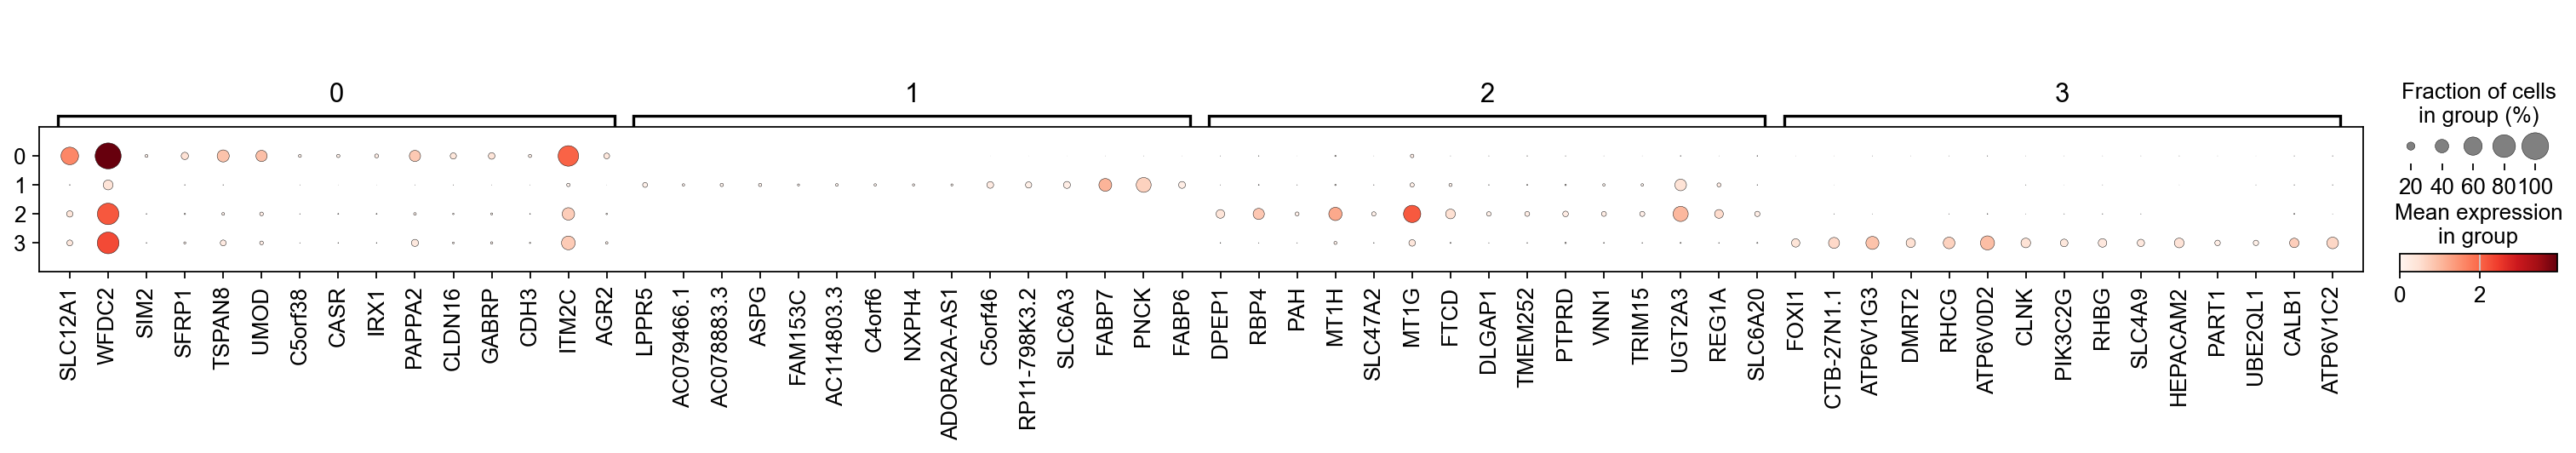

In [34]:

# 需求 B：我想要将这批基因变成一个大列表，用于后续画 Dotplot 或 Heatmap
top15_genes_unique = top15_markers['names'].unique().tolist()

# 使用提取出的基因画气泡图
sc.pl.dotplot(adata, top15_genes_dict, groupby='leiden')

In [57]:
new_cluster_names = {
    '0': "CD8 T",
    '1': "B",
    '2': "CD4 T",
    '3': "CD4 T",
    '4': "CD14+ Mono",
    '5': "NK",
    '6': "FCGR3A+ Mono",
    '7': "DC",
    '8': "Platelet"
}
#adata.rename_categories("louvain", new_cluster_names)
adata.obs['leiden'] = adata.obs['leiden'].map(new_cluster_names)
adata.obs['leiden'] 

AAACATACAACCAC-1         CD8 T
AAACATTGAGCTAC-1             B
AAACATTGATCAGC-1         CD4 T
AAACCGTGCTTCCG-1    CD14+ Mono
AAACCGTGTATGCG-1            NK
                       ...    
TTTCGAACTCTCAT-1    CD14+ Mono
TTTCTACTGAGGCA-1             B
TTTCTACTTCCTCG-1             B
TTTGCATGAGAGGC-1             B
TTTGCATGCCTCAC-1         CD4 T
Name: leiden, Length: 2638, dtype: object

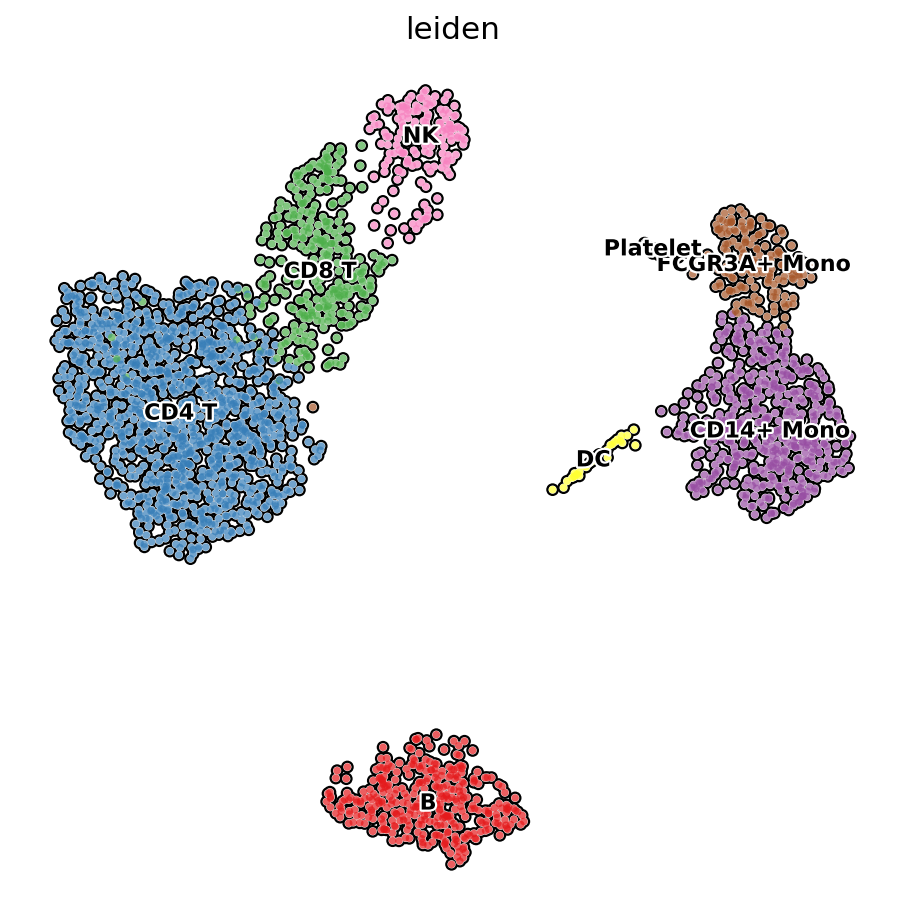

In [ ]:

fig, ax = plt.subplots(figsize=(7, 7))

# 使用 scanpy.pl.umap() 绘制 UMAP 图，并将图形绘制到指定的 Axes 对象上
sc.pl.umap(adata, color='leiden', legend_loc='on data',
           frameon=False, legend_fontsize=10, legend_fontoutline=2,
           add_outline=True, palette="Set1", ax=ax)
# 显示图表
plt.show()

#### 7.2 用seaborn美化umap图

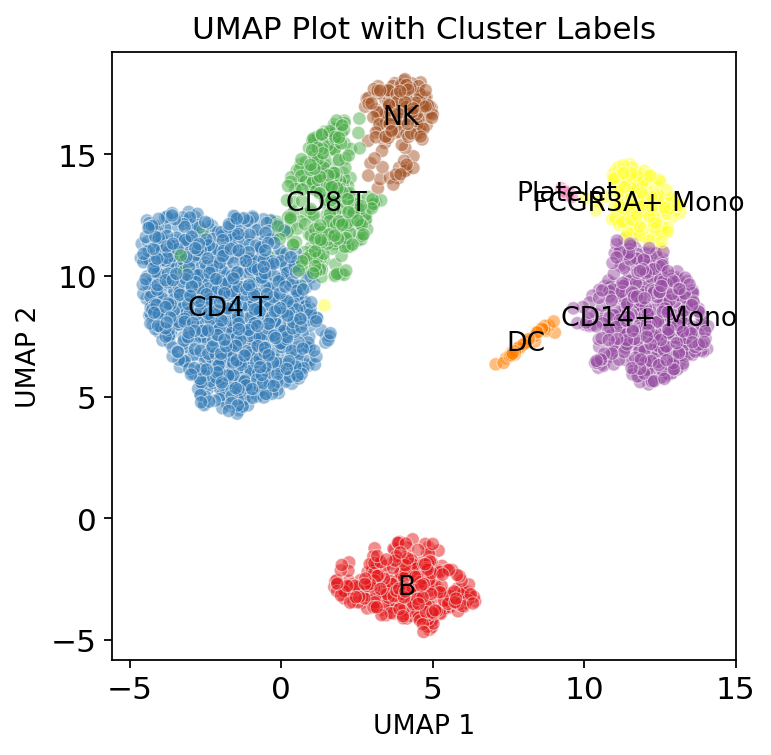

In [ ]:
umap_df = pd.DataFrame({
    'UMAP_1': adata.obsm['X_umap'][:, 0],
    'UMAP_2': adata.obsm['X_umap'][:, 1],
    'Cluster': adata.obs['leiden']
})

plt.figure(figsize=(5, 5))

# 使用 seaborn 绘制散点图，按 Cluster 着色
sns.scatterplot(
    data=umap_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='Cluster',
    palette='Set1',
    alpha=0.5,
    legend=None  # 不显示默认图例
)

# 计算每个 Cluster 的中心点并添加标签
unique_labels = umap_df['Cluster'].unique()
for label in unique_labels:
    label_coords = umap_df[umap_df['Cluster'] == label]
    center_x = label_coords['UMAP_1'].mean()
    center_y = label_coords['UMAP_2'].mean()
    plt.text(center_x, center_y, label, fontsize=12, ha='center', va='center')

# 图片设置
plt.grid(False)
plt.title('UMAP Plot with Cluster Labels', fontsize=14)
plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.show()

In [8]:
adata.write("adata.h5ad")

In [12]:
from sc_convert_utils import export_adata_for_seurat, adata_from_seuobj

# 加载已处理好的 adata
import scanpy as sc
adata = sc.read("adata.h5ad")

# 一行导出
export_adata_for_seurat(adata, output_dir="seurat_input")

📂 输出目录: seurat_input

✓ raw count matrix : 10706 cells × 18346 genes
⚠️  未找到 layers['lognorm']，使用当前 adata.X
   建议在 log1p 之后加：adata.layers['lognorm'] = csr_matrix(adata.X).copy()
✓ barcodes         : 10706 cells
✓ features         : 2268 genes
✓ metadata         : 10706 cells × 34 cols
✓ var metadata     : 2268 genes × 13 cols
✓ PCA embeddings   : 10706 cells × 50 PCs
✓ PCA loadings     : 2268 genes × 50 PCs
✓ UMAP embeddings  : 10706 cells × 2 dims

🎉 导出完成！文件清单:
  barcodes.tsv                           240.5 KB
  features.tsv                            17.8 KB
  matrix_lognorm.mtx                  579226.3 KB
  matrix_raw.mtx                      249910.8 KB
  metadata.csv                          3134.7 KB
  pca_embeddings.csv                    5874.7 KB
  pca_loadings.csv                      2400.4 KB
  umap_embeddings.csv                    441.2 KB
  var_metadata.csv                       373.8 KB
